In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
num_dropout_values = [3, 5, 10, 20, 50, 100, 500, 1000, 5000, 10000, 50000, 100000, 1000000]
datasets = {}
for num_dropout_value in num_dropout_values:
    filepath: str = f"/Users/leonardoalchieri/Desktop/GIT/MCDropoutHyperparameterAnalysis/experiments/verdojas_equation/results.nosync/mcdropout_{num_dropout_value}/regression_data_num_mcdropout_{num_dropout_value}_test.csv"
    data = pd.read_csv(filepath, index_col=0)
    datasets[num_dropout_value] = data

In [6]:
# merge the datasets, adding a new column for the number of dropout values
all_data = pd.concat(datasets, keys=num_dropout_values)
all_data = all_data.reset_index()
all_data = all_data.rename(columns={'level_0': 'num_dropout_values'})
all_data = all_data.drop(columns=['level_1'])

all_data['standardized variance'] = all_data.groupby('p')['variance'].transform(lambda x: (x - x.mean()) / x.std())
all_data['e'] = all_data.groupby('p')['standardized variance'].transform(lambda x: abs(x - x.iloc[-1]))

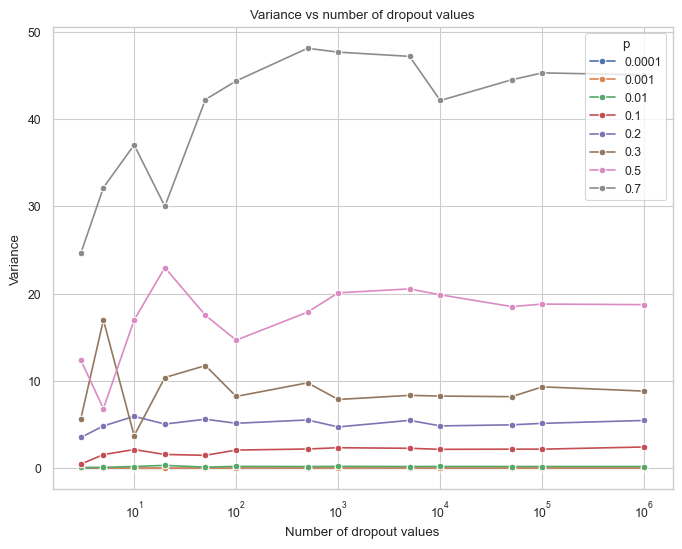

In [7]:
# make a plot where the x axis if num_dropout_values, the y axis variance and the hue is p
sns.set_theme(style="whitegrid")
sns.set_context("paper")
plt.figure(figsize=(8, 6))
all_data['p'] = all_data['p'].astype(str)
# exclude p = 0.9
all_data = all_data[all_data['p'] != '0.9']
ax = sns.lineplot(data=all_data, x='num_dropout_values', y='variance', hue='p', marker='o')
ax.set_xscale('log')
# ax.set_yscale('log')
plt.title("Variance vs number of dropout values")
plt.ylabel("Variance")
plt.xlabel("Number of dropout values")
# plt.savefig("variance_vs_num_dropout_values.png")
plt.show()

/Users/leonardoalchieri/mambaforge/envs/mcdropout/lib/python3.12/site-packages/pysr/sr.py:1238: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
/Users/leonardoalchieri/mambaforge/envs/mcdropout/lib/python3.12/site-packages/pysr/sr.py:1258: UserWarning: Note: Setting `random_state` without also setting `deterministic` to True and `procs` to 0 will result in non-deterministic searches. 
  warnings.warn(
/Users/leonardoalchieri/mambaforge/envs/mcdropout/lib/python3.12/site-packages/pysr/sr.py:1309: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Automatically setting `--heap-size-hint=343M` on each Julia process. You can configure this with the `heap_size_hint_in_bytes` parameter.
[ Info: Importing SymbolicRegression on workers.
[ Info: Finished!
[ Info: Testing module on workers...
[ Info: Finished!
[ Info: Testing entire pi


Expressions evaluated per second: 4.400e+05
Head worker occupation: 50.9%. This is high, and will prevent efficient resource usage. Increase `ncycles_per_iteration` to reduce load on head worker.
Progress: 511 / 5000 total iterations (10.220%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           1.125e+00  3.604e+01  y = 0.048845
2           7.228e-01  4.425e-01  y = square(-0.8264)
3           7.228e-01  2.952e-08  y = 1.0845 / 1.5879
4           3.804e-01  6.420e-01  y = square(2.7754) / x₀
5           3.073e-01  2.132e-01  y = (5.9035 / x₀) - -0.35483
6           3.036e-01  1.230e-02  y = (square(-2.5185) / x₀) - -0.35483
7           3.031e-01  1.630e-03  y = (square(square(1.5879)) / x₀) + 0.33902
8           3.005e-01  8.692e-03  y = (square(2.7286) / (x₀ + 0.75197)) - -0.34637
9           2.997e-01  2.527e-03  y = (square(2.7286) / (x₀ + square(0.75197))) - -0.34637

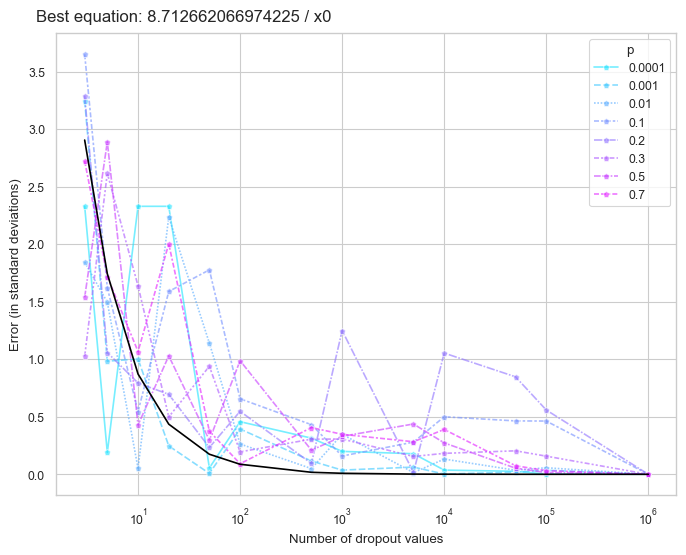

In [11]:
# make a plot where the x axis if num_dropout_values, the y axis variance and the hue is p
sns.set_theme(style="whitegrid")
sns.set_context("paper")
plt.figure(figsize=(8, 6))
all_data['p'] = all_data['p'].astype(str)
# exclude p = 0.9
all_data = all_data[all_data['p'] != '0.9']
ax = sns.lineplot(data=all_data, x='num_dropout_values', y='e', hue='p', style='p', marker='p', palette='cool', alpha=0.6)
ax.set_xscale('log')
# ax.set_yscale('log')
plt.ylabel("Error (in standard deviations)")
plt.xlabel("Number of dropout values")

# make a symbolic regression fit, draw the line and print the formula
from pysr import PySRRegressor

model = PySRRegressor(
        niterations=100,  # < Increase me for better results
        populations=50,
        population_size=33,
        ncycles_per_iteration=550 * 2,
        maxsize=50,
        # ncycles_per_iteration=50,
        binary_operators=["+", "-", "*", "/"],
        #   "^"],
        unary_operators=[
            # "inv(x) = 1/x",
            # ^ Custom operator (julia syntax)
            "square",
            # "cube",
            # "exp",
            # "abs",
            # "log",
            # "log10",
            # "log2",
            # "log1p",
            # "sqrt",
        ],
        random_state=42,
        procs=9,
        multithreading=False,
        batching=True,
        temp_equation_file=True,
        tempdir=None,
        delete_tempfiles=False,
        # heap_size_hint_in_bytes=int(2e10),
        precision=64,
        # turbo=True,
        # bumper=True,
        # deterministic=True,
        # equation_file=os.path.join(path_to_save, f"equation_{outer_fold}.csv"),
    )
X = all_data[['num_dropout_values']].values
y = all_data['e'].values

model.fit(
        X,
        y,
    )

# Print the equation
# print(model.equation_)

# plot the model predictions over the existing plot
import numpy as np
y_pred = model.predict(X)
plt.plot(X, y_pred, label='Symbolic Regression Fit', color='black')
best_equation = model.get_best()['equation']
# add a text box with the equation
plt.text(0.1, 0.9, f"Best equation: {best_equation}", fontsize=12, transform=plt.gcf().transFigure)

plt.savefig("./plots/variance_vs_num_dropout_values.pdf")
plt.show()

/Users/leonardoalchieri/mambaforge/envs/mcdropout/lib/python3.12/site-packages/pysr/sr.py:1238: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
/Users/leonardoalchieri/mambaforge/envs/mcdropout/lib/python3.12/site-packages/pysr/sr.py:1258: UserWarning: Note: Setting `random_state` without also setting `deterministic` to True and `procs` to 0 will result in non-deterministic searches. 
  warnings.warn(
/Users/leonardoalchieri/mambaforge/envs/mcdropout/lib/python3.12/site-packages/pysr/sr.py:1309: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Automatically setting `--heap-size-hint=1398M` on each Julia process. You can configure this with the `heap_size_hint_in_bytes` parameter.
[ Info: Importing SymbolicRegression on workers.
[ Info: Finished!
[ Info: Testing module on workers...
[ Info: Finished!
[ Info: Testing entire p


Expressions evaluated per second: 5.030e+05
Head worker occupation: 48.3%. This is high, and will prevent efficient resource usage. Increase `ncycles_per_iteration` to reduce load on head worker.
Progress: 582 / 5000 total iterations (11.640%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
2           7.228e-01  1.802e+01  y = square(0.82602)
4           7.228e-01  2.235e-07  y = square(0.56721 + 0.25895)
6           7.222e-01  3.949e-04  y = square(-0.8137 - (0.078457 * x₀))
7           7.215e-01  9.880e-04  y = 0.64389 + ((0.64389 - x₀) * x₀)
8           7.212e-01  3.890e-04  y = ((x₀ - -0.72923) / 1.2323) - square(x₀)
12          7.209e-01  8.604e-05  y = (square(square(x₀ + (-1.4907 + square(0.52826)))) * x₀) + ...
                                  0.52826
13          7.183e-01  3.704e-03  y = (square(square(square(x₀ + (-1.4907 + square(0.52826))))) ...
                   

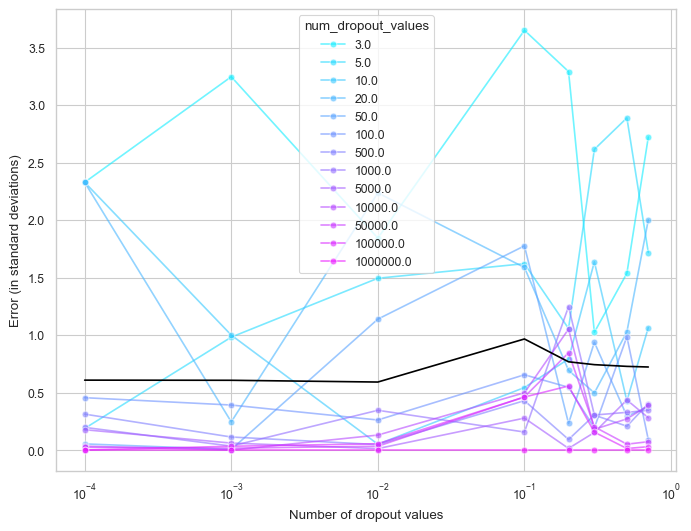

In [ ]:
# make a plot where the x axis if num_dropout_values, the y axis variance and the hue is p
sns.set_theme(style="whitegrid")
sns.set_context("paper")
plt.figure(figsize=(8, 6))
all_data['num_dropout_values'] = all_data['num_dropout_values'].astype(str)
all_data['p'] = all_data['p'].astype(float)
# exclude p = 0.9
ax = sns.lineplot(data=all_data, x='p', y='e', hue='num_dropout_values', 
                  marker='o',
                #   style='num_dropout_values', 
                #   marker='num_dropout_values', 
                  palette='cool', alpha=0.6)
ax.set_xscale('log')
# ax.set_yscale('log')
plt.ylabel("Error (in standard deviations)")
plt.xlabel("Number of dropout values")

# make a symbolic regression fit, draw the line and print the formula
from pysr import PySRRegressor

model = PySRRegressor(
        niterations=100,  # < Increase me for better results
        populations=50,
        population_size=33,
        ncycles_per_iteration=550 * 2,
        maxsize=50,
        # ncycles_per_iteration=50,
        binary_operators=["+", "-", "*", "/"],
        #   "^"],
        unary_operators=[
            # "inv(x) = 1/x",
            # ^ Custom operator (julia syntax)
            "square",
            # "cube",
            # "exp",
            # "abs",
            # "log",
            # "log10",
            # "log2",
            # "log1p",
            # "sqrt",
        ],
        random_state=42,
        procs=9,
        multithreading=False,
        batching=True,
        temp_equation_file=True,
        tempdir=None,
        delete_tempfiles=False,
        # heap_size_hint_in_bytes=int(2e10),
        precision=64,
        # turbo=True,
        # bumper=True,
        # deterministic=True,
        # equation_file=os.path.join(path_to_save, f"equation_{outer_fold}.csv"),
    )
all_data = all_data.sort_values(by='p')
X = all_data[['p']].values
y = all_data['e'].values

model.fit(
        X,
        y,
    )

# Print the equation
# print(model.equation_)

# plot the model predictions over the existing plot
import numpy as np
y_pred = model.predict(X)
print(y_pred)
plt.plot(X, y_pred, label='Symbolic Regression Fit', color='black')


# plt.savefig("variance_vs_num_dropout_values.png")
plt.show()

In [10]:
model.get_best()

complexity                                          3
loss                                         0.379168
score                                        0.645099
equation                        8.03841668721101 / x0
sympy_format                      8.03841668721101/x0
lambda_format    PySRFunction(X=>8.03841668721101/x0)
Name: 2, dtype: object

In [12]:
# # make a plot where the x axis if num_dropout_values, the y axis variance and the hue is p
# sns.set_theme(style="whitegrid")
# sns.set_context("paper")
# plt.figure(figsize=(8, 6))
# all_data['p'] = all_data['p'].astype(str)
# # exclude p = 0.9
# all_data = all_data[all_data['p'] != '0.9']
# # compute the absolute difference between variance at 1000000 and all other values. Call this column e
# all_data['e'] = all_data.groupby('p')['variance'].transform(lambda x: x - x.iloc[-1])
# ax = sns.lineplot(data=all_data, x='num_dropout_values', y='e', hue='p', marker='o')
# ax.set_xscale('log')
# plt.title("Variance vs number of dropout values")
# plt.ylabel("Variance")
# plt.xlabel("Number of dropout values")
# # plt.savefig("variance_vs_num_dropout_values.png")
# plt.show()

In [13]:
# # make a plot where the x axis if num_dropout_values, the y axis variance and the hue is p
# sns.set_theme(style="whitegrid")
# sns.set_context("paper")
# plt.figure(figsize=(8, 6))
# all_data['p'] = all_data['p'].astype(str)
# # standardize the variance, for each value of p
# all_data['variance'] = all_data.groupby('p')['variance'].transform(lambda x: (x - x.mean()) / x.std())
# ax = sns.lineplot(data=all_data, x='num_dropout_values', y='variance', hue='p', marker='o', alpha=0.4)
# # compute the average of the variance and its confidence interval
# average_variance = all_data.groupby('num_dropout_values')['variance'].mean()
# std_variance = all_data.groupby('num_dropout_values')['variance'].std() / all_data.groupby('num_dropout_values')['variance'].count() ** 0.5
# # plot a line with errorbars
# plt.errorbar(average_variance.index, average_variance, yerr=std_variance, fmt='-o', color='black')
# ax.set_xscale('log')
# plt.title("Variance vs number of dropout values")
# plt.ylabel("Variance")
# plt.xlabel("Number of dropout values")
# # plt.savefig("variance_vs_num_dropout_values.png")
# plt.show()

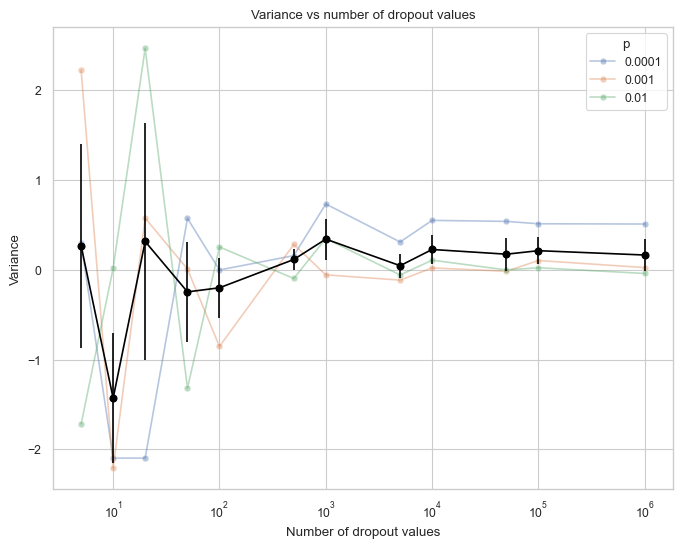

In [7]:
# # make a plot where the x axis if num_dropout_values, the y axis variance and the hue is p
# sns.set_theme(style="whitegrid")
# sns.set_context("paper")
# plt.figure(figsize=(8, 6))
# # all_data['p'] = all_data['p'].astype(float)
# # all_data = all_data[all_data['p'] < 0.1]
# all_data['p'] = all_data['p'].astype(str)
# # standardize the variance, for each value of p
# all_data['standardized variance'] = all_data.groupby('p')['variance'].transform(lambda x: (x - x.mean()) / x.std())
# ax = sns.lineplot(data=all_data, x='num_dropout_values', y='standardized variance', hue='p', marker='o', alpha=0.4)
# # compute the average of the variance and its confidence interval
# average_variance = all_data.groupby('num_dropout_values')['standardized variance'].mean()
# std_variance = all_data.groupby('num_dropout_values')['standardized variance'].std() / all_data.groupby('num_dropout_values')['variance'].count() ** 0.5
# # plot a line with errorbars
# plt.errorbar(average_variance.index, average_variance, yerr=std_variance, fmt='-o', color='black')
# ax.set_xscale('log')
# plt.title("Variance vs number of dropout values")
# plt.ylabel("Variance")
# plt.xlabel("Number of dropout values")
# # plt.savefig("variance_vs_num_dropout_values.png")
# plt.show()

<Figure size 800x600 with 0 Axes>

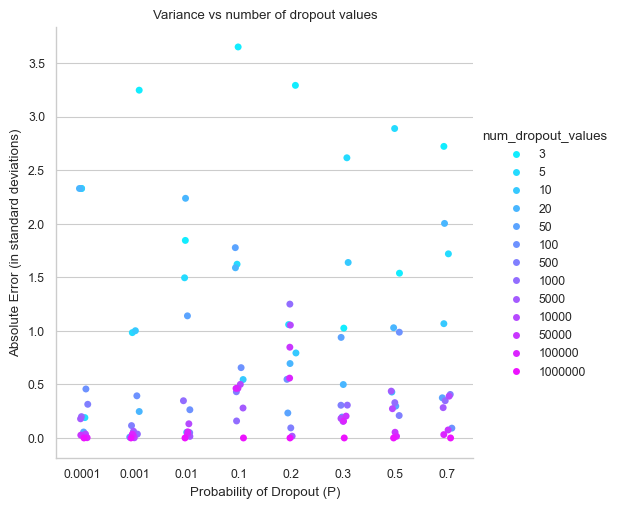

In [38]:
# make a plot where the x axis if num_dropout_values, the y axis variance and the hue is p
sns.set_theme(style="whitegrid")
sns.set_context("paper")
plt.figure(figsize=(8, 6))
all_data['p'] = all_data['p'].astype(str)
# exclude p = 0.9
all_data = all_data[all_data['p'] != '0.9']

all_data['num_dropout_values'] = all_data['num_dropout_values'].astype(str)
# compute the absolute difference between variance at 1000000 and all other values. Call this column e
ax = sns.catplot(data=all_data, x='p', y='e', hue='num_dropout_values', palette='cool', marker='o')
# ax.set_yscale('symlog')
# move the legend all the way to the right
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Number of dropout values")
plt.title("Variance vs number of dropout values")
plt.ylabel("Absolute Error (in standard deviations)")
plt.xlabel("Probability of Dropout (P)")
# plt.savefig("variance_vs_num_dropout_values.png")
plt.show()